In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
df = pd.read_csv('../Dataset/Housing.csv')
print("Dataset loaded! Shape:", df.shape)
df.head()   # Shows first 5 rows

Dataset loaded! Shape: (545, 13)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [3]:
# Check missing values
print(df.isnull().sum())

# No major missing values in this dataset, but if any:
df = df.dropna()  # Remove rows with missing data (safe here)
print("Data cleaned!")

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64
Data cleaned!


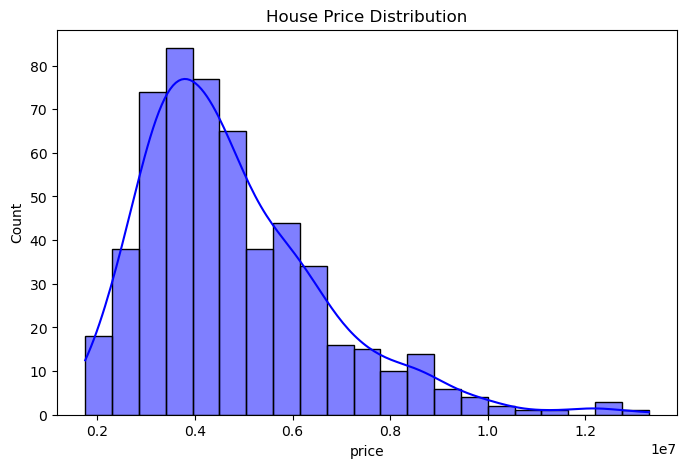

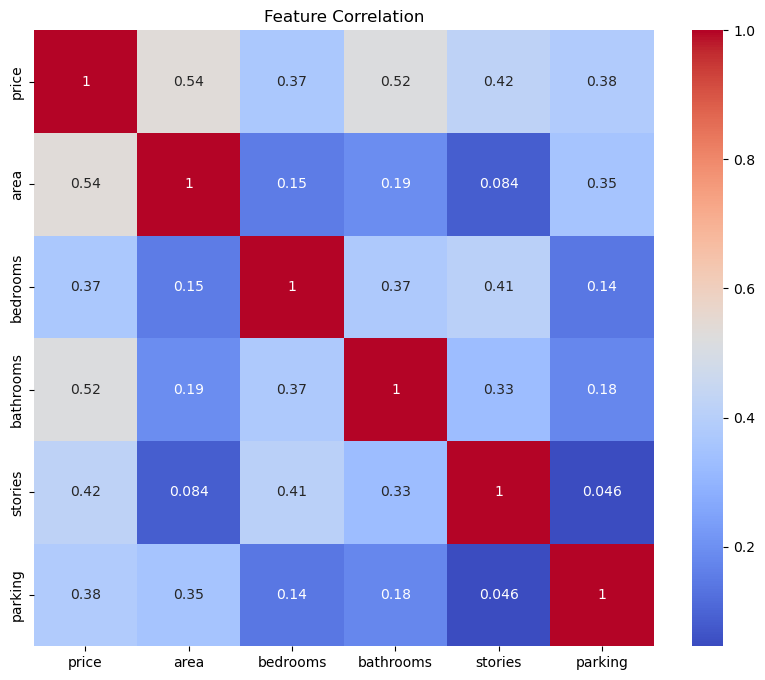

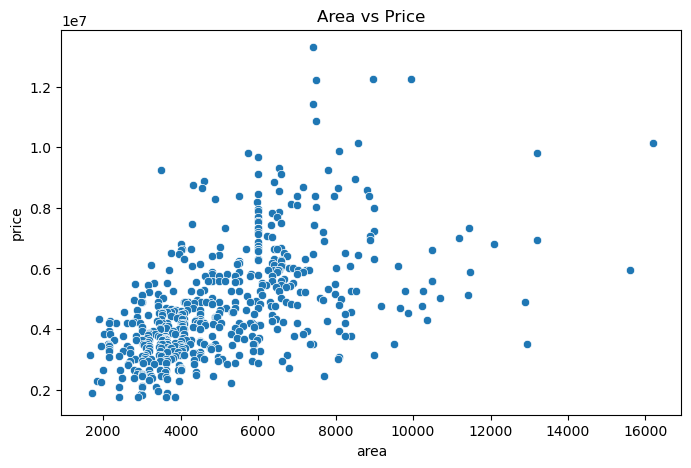

In [4]:
# 1. Price Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['price'], kde=True, color='blue')
plt.title('House Price Distribution')
plt.savefig('../Documentation/price_distribution.png')
plt.show()

# 2. Correlation Heatmap
plt.figure(figsize=(10,8))
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation')
plt.savefig('../Documentation/correlation_heatmap.png')
plt.show()

# 3. Area vs Price Scatter
plt.figure(figsize=(8,5))
sns.scatterplot(x='area', y='price', data=df)
plt.title('Area vs Price')
plt.savefig('../Documentation/area_vs_price.png')
plt.show()

In [5]:
# Create one new useful feature
df['price_per_sqft'] = df['price'] / df['area']

print("New feature created!")
df.head()

New feature created!


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,price_per_sqft
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished,1792.452830
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished,1367.187500
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished,1229.919679
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished,1628.666667
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished,1537.735849


In [6]:
X = df.drop('price', axis=1)   # Features
y = df['price']                # Target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split done!")

Data split done!


In [8]:
# Define preprocessing
numeric_features = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']
categorical_features = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 
                       'airconditioning', 'prefarea', 'furnishingstatus']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Three models
models = {
    'Linear_Regression': Pipeline([('prep', preprocessor), ('model', LinearRegression())]),
    'Random_Forest': Pipeline([('prep', preprocessor), ('model', RandomForestRegressor(n_estimators=100, random_state=42))]),
    'XGBoost': Pipeline([('prep', preprocessor), ('model', XGBRegressor(random_state=42))])
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    results[name] = {
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'R2': r2_score(y_test, y_pred)
    }
    
    # Save model
    joblib.dump(model, f'../Model/{name}.pkl')
    print(f"{name} trained and saved!")

print("\nModel Performance:")
for name, metrics in results.items():
    print(name, metrics)

Linear_Regression trained and saved!
Random_Forest trained and saved!
XGBoost trained and saved!

Model Performance:
Linear_Regression {'MAE': 970043.4039201644, 'RMSE': np.float64(1324506.9600914405), 'R2': 0.6529242642153175}
Random_Forest {'MAE': 1025961.1683486238, 'RMSE': np.float64(1403925.371676078), 'R2': 0.610054593532394}
XGBoost {'MAE': 1057455.0, 'RMSE': np.float64(1438064.4086382224), 'R2': 0.5908595323562622}


In [10]:
# Create model comparison table
import pandas as pd

comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'MAE': [results['Linear_Regression']['MAE'], 
            results['Random_Forest']['MAE'], 
            results['XGBoost']['MAE']],
    'RMSE': [results['Linear_Regression']['RMSE'], 
             results['Random_Forest']['RMSE'], 
             results['XGBoost']['RMSE']],
    'R2 Score': [results['Linear_Regression']['R2'], 
                 results['Random_Forest']['R2'], 
                 results['XGBoost']['R2']]
})

print("Model Comparison Table:")
print(comparison.round(2))   # Show in notebook

# Save as CSV (Good for report)
comparison.to_csv('../Documentation/model_comparison.csv', index=False)
print("✅ Saved as CSV: model_comparison.csv")

# Save as Excel (Even better for report)
comparison.to_excel('../Documentation/model_comparison.xlsx', index=False)
print("✅ Saved as Excel: model_comparison.xlsx")

Model Comparison Table:
               Model         MAE        RMSE  R2 Score
0  Linear Regression   970043.40  1324506.96      0.65
1      Random Forest  1025961.17  1403925.37      0.61
2            XGBoost  1057455.00  1438064.41      0.59
✅ Saved as CSV: model_comparison.csv
✅ Saved as Excel: model_comparison.xlsx


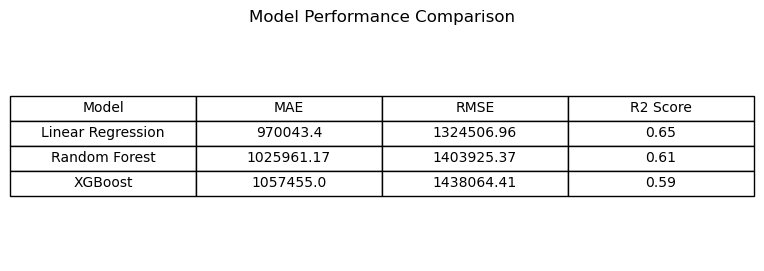

✅ Table image saved successfully!


In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 3))
ax.axis('tight')
ax.axis('off')

table = ax.table(cellText=comparison.round(2).values,
                 colLabels=comparison.columns,
                 cellLoc='center',
                 loc='center')

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

plt.title("Model Performance Comparison")
plt.savefig('../Documentation/model_comparison.png', bbox_inches='tight', dpi=300)
plt.show()

print("✅ Table image saved successfully!")